In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from scipy.stats import uniform, loguniform, norm
from sklearn.gaussian_process.kernels import Matern, RBF, WhiteKernel, ConstantKernel as C
from scipy.optimize import minimize
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score

## **Function 5** - Chemical Process Optimisation

- A black box function which represents the yield of a chemical process in a factory. The function is typically unimodal, with a single peak where yield is maximised.

- **Main goal** - find the optimal combination of chemical inputs that delivers the highest possible yield, using systematic exploration and optimisation methods.

- **Input** - 4D (20,4)
- **Output** - 4D (20,)

- **Goal** - Maximise

In [2]:
X = np.load(r'/Users/pratham/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_5/initial_inputs.npy')
Y = np.load(r'/Users/pratham/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_5/initial_outputs.npy')

In [4]:
# New data from Week 3 (Function 5)
X_w2_new_point = np.array([0.236596, 0.865457, 0.892890, 0.897109], dtype=np.float64)
Y_w2_new_point = np.array([1339.5571827332535], dtype=np.float64)

# Append the new data points
X_updated = np.vstack((X, X_w2_new_point.reshape(1, -1)))
X_unique, unique_indices = np.unique(X_updated, axis=0, return_index=True)
Y_updated = np.append(Y, Y_w2_new_point)[unique_indices]

# Save the updated arrays
np.save('/Users/pratham/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_5/initial_inputs.npy', X_unique)
np.save('/Users/pratham/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_5/initial_outputs.npy', Y_updated)

In [6]:
# Show updated arrays
print("Updated Inputs (X) - Function 5: ", X_unique)
print("Updated Outputs (Y) - Function 5: ", Y_updated)

Updated Inputs (X) - Function 5:  [[0.11987923 0.86254031 0.64333133 0.84980383]
 [0.12688467 0.15342962 0.77016219 0.19051811]
 [0.15378571 0.72938169 0.42259844 0.44307417]
 [0.19144708 0.03819337 0.60741781 0.41458414]
 [0.22418902 0.84648049 0.87948418 0.87851568]
 [0.236596   0.865457   0.89289    0.897109  ]
 [0.30688872 0.31687813 0.62263448 0.09539906]
 [0.35235627 0.32224153 0.11697937 0.47311252]
 [0.35548161 0.63961937 0.41761768 0.12260384]
 [0.43834987 0.8043397  0.21024527 0.15129482]
 [0.43893338 0.77409176 0.37816709 0.93369621]
 [0.46344227 0.63002451 0.10790646 0.9576439 ]
 [0.51114177 0.817957   0.72871042 0.11235362]
 [0.55362148 0.66734998 0.32380582 0.81486975]
 [0.55421    0.123984   0.678221   0.890122  ]
 [0.58397341 0.14724265 0.34809746 0.42861465]
 [0.67749115 0.35850951 0.47959222 0.07288048]
 [0.68343225 0.11866264 0.82904591 0.56757661]
 [0.70605083 0.53419196 0.26424335 0.48208755]
 [0.72526172 0.47987049 0.08894684 0.75976022]
 [0.75865295 0.53651774 0.

### **Interpretation of the Output**

$1339.55$ is is a very high output. In a simulation context, this indicates that I have either found the "optimal" state or am very close to it. 

The goal now is to "drill" exactly where I can find the absolute peak. Because the scale is so large ($10^3$), the Gaussian Process will see a very steep slope. 

If we don't normalize the data, the model might become numerically unstable or overfit the peak, ignoring everything else.So, I am sticking to continued Exploitation around this peak.

### **Bayesian Optimisation** - Gaussian Processes

I am not changing anything with the current kernel choice and how the model is set up.

In [8]:
kernel = Matern(
    length_scale=[0.1]*4, 
    length_scale_bounds="fixed", 
    nu=2.5
)

model = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-6,               # Stability for narrow peak optimization
    n_restarts_optimizer=25,
    normalize_y=True
)

model.fit(X_unique, Y_updated)

,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".","Matern(length... 0.1], nu=2.5)"
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",1e-06
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",25
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",True
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:

### Acquisition Function - Expected Improvement (EI)

- I am sticking to the same model and not changing the `xi = 0.001` as I want to find out if there is anything even 0.1% better than the current output.

In [9]:
def expected_improvement(X_grid, model, y_max, xi=0.001):

    mu, sigma = model.predict(X_grid, return_std=True)
    mu, sigma = mu.reshape(-1, 1), sigma.reshape(-1, 1)

    with np.errstate(divide='ignore', invalid='ignore'):
        improvement = mu - y_max - xi
        Z = improvement / (sigma + 1e-9)
        ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma <= 0.0] = 0.0

    return ei.ravel()

# Calculate the values using the function
y_max = np.max(Y_updated)
x_grid = np.random.uniform(0, 1, size=(100000, 4))
ei_values = expected_improvement(x_grid, model, y_max, xi=0.01)

# Find the best index from the calculated values
best_idx = np.argmax(ei_values)
next_query = x_grid[best_idx]

print(f"Next Submission for Function 5 - Bayesian Optimisation (EI): "
f"{next_query[0]:.6f}-{next_query[1]:.6f}-{next_query[2]:.6f}-{next_query[3]:.6f}")


Next Submission for Function 5 - Bayesian Optimisation (EI): 0.221849-0.896815-0.894595-0.898055


### **Visualisation of the Output**

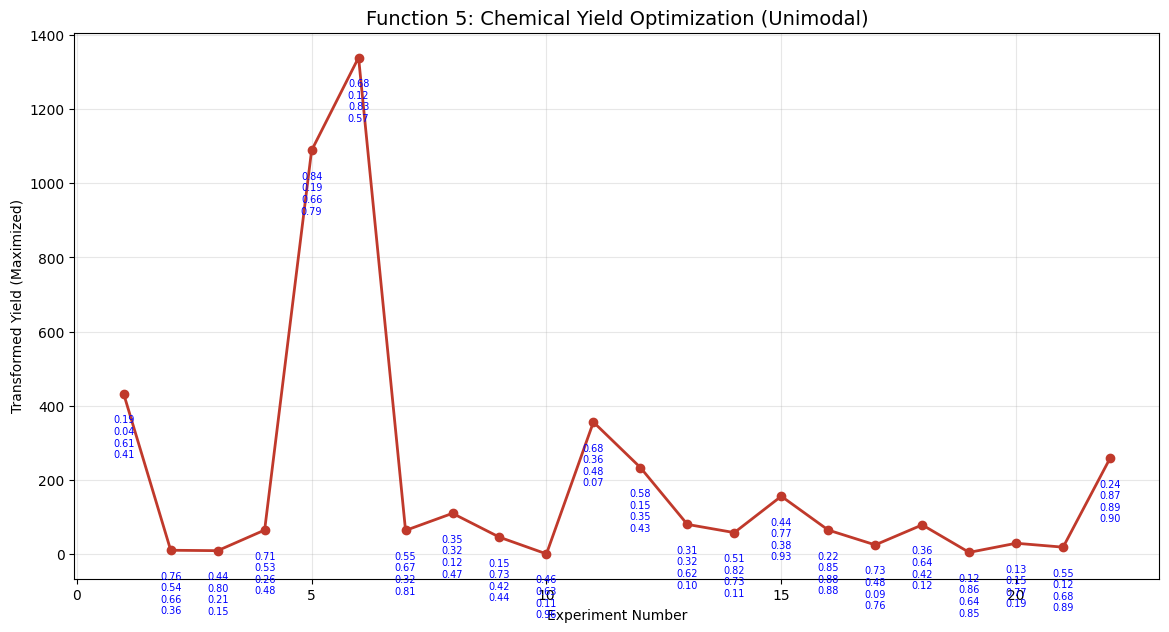

In [10]:
iterations = np.arange(1, len(Y_updated) + 1)
plt.figure(figsize=(14, 7))
plt.plot(iterations, Y_updated, marker='o', linestyle='-', color='#c0392b', linewidth=2)

for i in range(len(Y_updated)):
    # Stacked inputs: x1 (temp), x2 (pressure), x3 (conc), x4 (time)
    input_label = f"{X_updated[i,0]:.2f}\n{X_updated[i,1]:.2f}\n{X_updated[i,2]:.2f}\n{X_updated[i,3]:.2f}"
    
    plt.annotate(input_label, 
                 (iterations[i], Y_updated[i]), 
                 textcoords="offset points", 
                 xytext=(0, -15), 
                 va='top', 
                 ha='center', 
                 fontsize=7,
                 linespacing=1.2,
                 color = 'blue')

plt.title('Function 5: Chemical Yield Optimization (Unimodal)', fontsize=14)
plt.xlabel('Experiment Number')
plt.ylabel('Transformed Yield (Maximized)')
plt.subplots_adjust(bottom=0.1) # Extra space for stacked labels
plt.grid(True, alpha=0.3)
plt.show()